# 1. Importing and Loading Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
operation_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Operations_DA/sales_data.csv')

# 2. Visualizing and understanding dataset


In [ ]:
operation_data.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [ ]:
operation_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

In [ ]:
operation_data.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


# 3. Cleaning & Preprocessing

In [ ]:
operation_data.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Price,0
Discount,0


In [ ]:
operation_data.duplicated().sum()
print(f"Number of duplicated rows: {operation_data.duplicated().sum()}")

Number of duplicated rows: 0


In [ ]:
operation_data['Date'] = pd.to_datetime(operation_data['Date'])
operation_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[ns]
 1   Store ID            76000 non-null  object        
 2   Product ID          76000 non-null  object        
 3   Category            76000 non-null  object        
 4   Region              76000 non-null  object        
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  object        
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  object    

In [ ]:
# Saving dataset
official_dataset_path = "./operations_official_dataset.csv"
operation_data.to_csv(official_dataset_path, index=False, encoding="utf-8")
print(f"Saving to: {official_dataset_path}")

Saving to: ./operations_official_dataset.csv


# 4. Data Analysis

In [ ]:
df_aggregated = operation_data.groupby(['Date', 'Product ID'])[['Units Sold', 'Demand']].sum().reset_index()
print(f"Aggregated DataFrame head: {df_aggregated.head()}")

Aggregated DataFrame head:         Date Product ID  Units Sold  Demand
0 2022-01-01      P0001         473     510
1 2022-01-01      P0002         490     714
2 2022-01-01      P0003         640     711
3 2022-01-01      P0004         509     527
4 2022-01-01      P0005         531     541


## Perform ABC Analysis based on 'Units Sold'

### Subtask:
Calculate the total 'Units Sold' for each 'Product ID' over the entire period. Sort products by total 'Units Sold' in descending order and calculate the cumulative total and cumulative percentage contribution. Classify products into A, B, C categories based on percentage thresholds (e.g., A for 80% of total sales, B for the next 15%, C for the remaining 5%) to identify the most important items in terms of sales.

**Reasoning**:
First, I need to calculate the total 'Units Sold' for each 'Product ID' from the `df_aggregated` DataFrame, sort them, calculate the cumulative sum, and the cumulative percentage of 'Units Sold'. This will prepare the data for the ABC classification.



In [ ]:
df_abc = df_aggregated.groupby('Product ID')['Units Sold'].sum().reset_index()
df_abc = df_abc.sort_values(by='Units Sold', ascending=False).reset_index(drop=True)
df_abc['Cumulative Units Sold'] = df_abc['Units Sold'].cumsum()
df_abc['Cumulative Percentage'] = (df_abc['Cumulative Units Sold'] / df_abc['Units Sold'].sum()) * 100

def abc_classify(percentage):
    if percentage <= 80:
        return 'A'
    elif percentage <= 95:
        return 'B'
    else:
        return 'C'

df_abc['ABC Class'] = df_abc['Cumulative Percentage'].apply(abc_classify)

print(df_abc.head())
print(f"\nABC Classification Counts:\n{df_abc['ABC Class'].value_counts()}")

df_abc.to_csv('ABC_dataset.csv', index=False)

  Product ID  Units Sold  Cumulative Units Sold  Cumulative Percentage  \
0      P0007      379709                 379709               5.624589   
1      P0004      377627                 757336              11.218337   
2      P0009      376771                1134107              16.799405   
3      P0013      376717                1510824              22.379673   
4      P0002      359355                1870179              27.702760   

  ABC Class  
0         A  
1         A  
2         A  
3         A  
4         A  

ABC Classification Counts:
ABC Class
A    15
B     3
C     2
Name: count, dtype: int64
Saving to: ABC_dataset.csv


## Perform XYZ Analysis based on 'Demand' variability

### Subtask:
For each 'Product ID', calculate the mean and standard deviation of 'Demand' over time. Then, calculate the Coefficient of Variation (CV = Standard Deviation / Mean). Classify products into X, Y, Z categories based on defined CV thresholds (e.g., X for low CV <10%, Y for medium CV from 10-25%, Z for high CV >25%) to assess demand stability.

**Reasoning**:
First, I need to calculate the mean and standard deviation of 'Demand' for each 'Product ID' from the `df_aggregated` DataFrame to prepare for the Coefficient of Variation (CV) calculation and subsequent XYZ classification.

**Note**: the `agg` function was provided with a tuple `
('Demand', 'mean')` when a single column ('Demand')
was already selected for aggregation. When aggregating a single column with named aggregations, the function name (e.g., 'mean', 'std') should be passed directly as a string to the `agg` function, not as a tuple with the column name.

In [ ]:
df_xyz = df_aggregated.groupby('Product ID')['Demand'].agg(Mean_Demand='mean', Std_Demand='std').reset_index()
# Don't do this: ...agg(Mean_Demand=('Demand', 'mean'), Std_Demand=('Demand', 'std')).reset_index()
df_xyz['CV'] = (df_xyz['Std_Demand'] / df_xyz['Mean_Demand']) * 100

def xyz_classify(cv_value):
    if cv_value < 10:
        return 'X'
    elif 10 <= cv_value <= 25:
        return 'Y'
    else:
        return 'Z'

df_xyz['XYZ Class'] = df_xyz['CV'].apply(xyz_classify)

print(df_xyz.head())
print(f"\nXYZ Classification Counts:\n{df_xyz['XYZ Class'].value_counts()}")

df_xyz.to_csv('XYZ_dataset.csv', index=False)

  Product ID  Mean_Demand  Std_Demand         CV XYZ Class
0      P0001   547.956579  148.093504  27.026503         Z
1      P0002   560.332895  146.586072  26.160533         Z
2      P0003   519.976316  140.920518  27.101334         Z
3      P0004   576.980263  162.083408  28.091673         Z
4      P0005   537.602632  140.612354  26.155444         Z

XYZ Classification Counts:
XYZ Class
Z    17
Y     3
Name: count, dtype: int64
Saving to: XYZ_dataset.csv


## Combine ABC and XYZ Classification

### Subtask:
Combine the ABC and XYZ classification results for each 'Product ID' to create a dual classification matrix (e.g., AX, AY, AZ, BX, BY, BZ, CX, CY, CZ). Visualize the distribution of these combined categories (e.g., using a frequency chart or stacked bar chart) to gain an overview of the product catalog.

**Reasoning**:
First, I need to merge `df_abc` and `df_xyz` DataFrames based on the 'Product ID' to combine the ABC and XYZ classification results. Then, I will create a new column 'ABC_XYZ_Class' by concatenating the 'ABC Class' and 'XYZ Class' from the merged DataFrame. Finally, I'll display the first few rows of the combined DataFrame and the counts of each combined category to verify the results.



In [ ]:
df_combined_classification = pd.merge(df_abc[['Product ID', 'ABC Class']], df_xyz[['Product ID', 'XYZ Class']], on='Product ID')
df_combined_classification['ABC_XYZ_Class'] = df_combined_classification['ABC Class'] + df_combined_classification['XYZ Class']


print(df_combined_classification.head())
print(f"\nCombined ABC-XYZ Classification Counts:\n{df_combined_classification['ABC_XYZ_Class'].value_counts()}")

  Product ID ABC Class XYZ Class ABC_XYZ_Class
0      P0007         A         Z            AZ
1      P0004         A         Z            AZ
2      P0009         A         Y            AY
3      P0013         A         Z            AZ
4      P0002         A         Z            AZ

Combined ABC-XYZ Classification Counts:
ABC_XYZ_Class
AZ    14
BY     2
CZ     2
AY     1
BZ     1
Name: count, dtype: int64


In [ ]:
df_combined = pd.merge(
    df_abc[['Product ID', 'Cumulative Units Sold', 'Cumulative Percentage']],
    df_xyz[['Product ID', 'Mean_Demand', 'Std_Demand', 'CV']],
    on='Product ID',
    how='left'
)
df_combined = pd.merge(
    df_combined,
    df_combined_classification[['Product ID', 'ABC Class', 'XYZ Class', 'ABC_XYZ_Class']],
    on='Product ID',
    how='left'
)

print(df_combined.head())

df_combined.to_csv('ABC_XYZ_Class_dataset.csv', index=False)

  Product ID  Cumulative Units Sold  Cumulative Percentage  Mean_Demand  \
0      P0007                 379709               5.624589   575.117105   
1      P0004                 757336              11.218337   576.980263   
2      P0009                1134107              16.799405   592.531579   
3      P0013                1510824              22.379673   580.125000   
4      P0002                1870179              27.702760   560.332895   

   Std_Demand         CV ABC Class XYZ Class ABC_XYZ_Class  
0  161.221493  28.032811         A         Z            AZ  
1  162.083408  28.091673         A         Z            AZ  
2  140.509365  23.713397         A         Y            AY  
3  167.826017  28.929285         A         Z            AZ  
4  146.586072  26.160533         A         Z            AZ  


**Reasoning**:
Now that the combined ABC-XYZ classifications are generated, the next step is to visualize their distribution as requested in the subtask. A bar plot will effectively show the frequency of each combined category.

**Note**:
I have to explicitly set hue to the x variable and legend=False in the sns.countplot function.

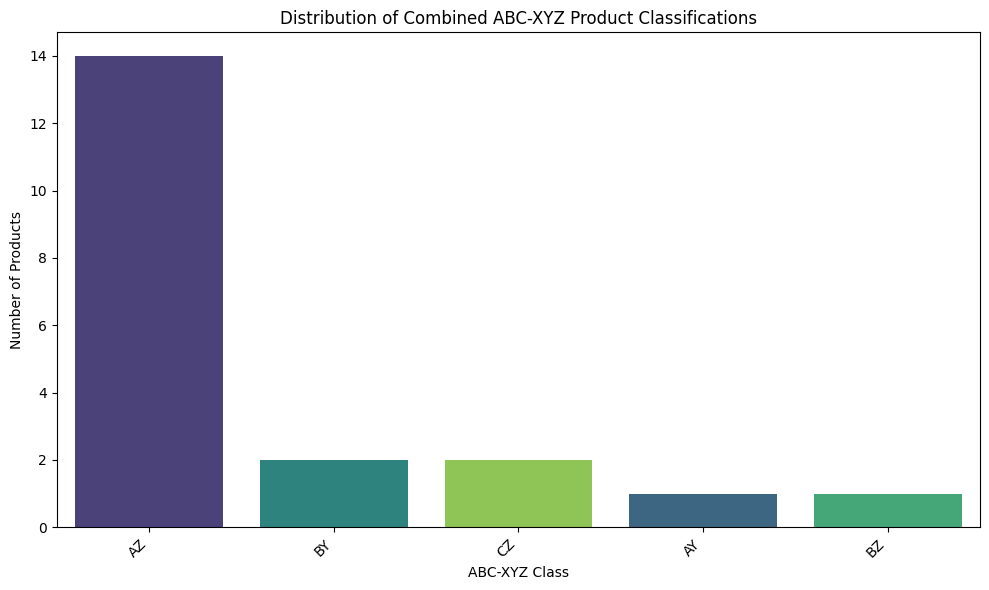

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_combined_classification,
    x='ABC_XYZ_Class',
    hue='ABC_XYZ_Class',
    order=df_combined_classification['ABC_XYZ_Class'].value_counts().index,
    palette='viridis',
    legend=False
    )
plt.title('Distribution of Combined ABC-XYZ Product Classifications')
plt.xlabel('ABC-XYZ Class')
plt.ylabel('Number of Products')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Feature Engineering and Dataset Splitting for Forecasting

### Subtask:
Create new features from the 'Date' column (year, month, day of week, day of year) and variables that may affect demand (e.g., 'Price', 'Discount', 'Promotion', 'Weather Condition', 'Seasonality', 'Epidemic', 'Competitor Pricing'). Split the dataset into training and testing sets to evaluate model performance.

**Reasoning**:
The first instruction is to create time-based features (year, month, day of week, day of year) from the 'Date' column of `df_aggregated` and add them as new columns. This will enrich the dataset with temporal information.



In [ ]:
df_aggregated['Year'] = df_aggregated['Date'].dt.year
df_aggregated['Month'] = df_aggregated['Date'].dt.month
df_aggregated['DayOfWeek'] = df_aggregated['Date'].dt.dayofweek
df_aggregated['DayOfYear'] = df_aggregated['Date'].dt.dayofyear

print(df_aggregated.head())

        Date Product ID  Units Sold  Demand  Year  Month  DayOfWeek  DayOfYear
0 2022-01-01      P0001         473     510  2022      1          5          1
1 2022-01-01      P0002         490     714  2022      1          5          1
2 2022-01-01      P0003         640     711  2022      1          5          1
3 2022-01-01      P0004         509     527  2022      1          5          1
4 2022-01-01      P0005         531     541  2022      1          5          1


**Reasoning**:
The next step is to aggregate the variables 'Price', 'Discount', and 'Competitor Pricing' from the `operation_data` DataFrame by calculating their mean for each 'Date' and 'Product ID' combination. This will create a new DataFrame with these aggregated features.



In [ ]:
df_price_features = operation_data.groupby(
    ['Date', 'Product ID'])[['Price','Discount', 'Competitor Pricing']].mean().reset_index()
print(df_price_features.head())

        Date Product ID   Price  Discount  Competitor Pricing
0 2022-01-01      P0001  40.478       4.0              40.902
1 2022-01-01      P0002  44.812      14.0              48.276
2 2022-01-01      P0003  81.002      16.0              72.090
3 2022-01-01      P0004  42.510       7.0              45.492
4 2022-01-01      P0005  55.162       3.0              53.900


**Reasoning**:
The next step is to aggregate the 'Promotion' and 'Epidemic' variables from the `operation_data` DataFrame by calculating their maximum value for each 'Date' and 'Product ID' combination. This will create a new DataFrame with these aggregated features, indicating if the event (promotion or epidemic) occurred on that specific date for that product.



In [ ]:
df_promo_epidemic_features = operation_data.groupby(['Date', 'Product ID'])[['Promotion', 'Epidemic']].max().reset_index()
print(df_promo_epidemic_features.head())

        Date Product ID  Promotion  Epidemic
0 2022-01-01      P0001          0         0
1 2022-01-01      P0002          1         0
2 2022-01-01      P0003          1         0
3 2022-01-01      P0004          0         0
4 2022-01-01      P0005          0         0


**Reasoning**:
The next step is to aggregate the 'Weather Condition' and 'Seasonality' variables from the `operation_data` DataFrame by taking the mode for each 'Date' and 'Product ID' combination. If multiple modes exist, the first one will be selected. This will create a new DataFrame with these aggregated features.



In [ ]:
df_categorical_features = operation_data.groupby(['Date', 'Product ID'])[['Weather Condition', 'Seasonality']].agg(lambda x: x.mode()[0]).reset_index()
print(df_categorical_features.head())

        Date Product ID Weather Condition Seasonality
0 2022-01-01      P0001             Snowy      Winter
1 2022-01-01      P0002             Snowy      Winter
2 2022-01-01      P0003             Snowy      Winter
3 2022-01-01      P0004             Snowy      Winter
4 2022-01-01      P0005             Snowy      Winter


**Reasoning**:
Now that the individual feature DataFrames (`df_price_features`, `df_promo_epidemic_features`, `df_categorical_features`) have been created, I will merge them into the `df_aggregated` DataFrame using 'Date' and 'Product ID' as keys. This step consolidates all the generated features into a single DataFrame for further processing.



In [ ]:
df_full_features = df_aggregated.merge(df_price_features, on=['Date', 'Product ID'], how='left')
df_full_features = df_full_features.merge(df_promo_epidemic_features, on=['Date', 'Product ID'], how='left')
df_full_features = df_full_features.merge(df_categorical_features, on=['Date', 'Product ID'], how='left')

print(df_full_features.head())

df_full_features.to_csv('Full_Features_dataset.csv', index=False)

        Date Product ID  Units Sold  Demand  Year  Month  DayOfWeek  \
0 2022-01-01      P0001         473     510  2022      1          5   
1 2022-01-01      P0002         490     714  2022      1          5   
2 2022-01-01      P0003         640     711  2022      1          5   
3 2022-01-01      P0004         509     527  2022      1          5   
4 2022-01-01      P0005         531     541  2022      1          5   

   DayOfYear   Price  Discount  Competitor Pricing  Promotion  Epidemic  \
0          1  40.478       4.0              40.902          0         0   
1          1  44.812      14.0              48.276          1         0   
2          1  81.002      16.0              72.090          1         0   
3          1  42.510       7.0              45.492          0         0   
4          1  55.162       3.0              53.900          0         0   

  Weather Condition Seasonality  
0             Snowy      Winter  
1             Snowy      Winter  
2             Snowy 

**Reasoning**:
The next step is to apply One-Hot Encoding to the categorical columns 'Weather Condition' and 'Seasonality' in the `df_full_features` DataFrame. This will convert these categorical variables into a numerical format suitable for machine learning models.



In [ ]:
df_full_features = pd.get_dummies(df_full_features, columns=['Weather Condition', 'Seasonality'], drop_first=True)
print(df_full_features.head())

        Date Product ID  Units Sold  Demand  Year  Month  DayOfWeek  \
0 2022-01-01      P0001         473     510  2022      1          5   
1 2022-01-01      P0002         490     714  2022      1          5   
2 2022-01-01      P0003         640     711  2022      1          5   
3 2022-01-01      P0004         509     527  2022      1          5   
4 2022-01-01      P0005         531     541  2022      1          5   

   DayOfYear   Price  Discount  Competitor Pricing  Promotion  Epidemic  \
0          1  40.478       4.0              40.902          0         0   
1          1  44.812      14.0              48.276          1         0   
2          1  81.002      16.0              72.090          1         0   
3          1  42.510       7.0              45.492          0         0   
4          1  55.162       3.0              53.900          0         0   

   Weather Condition_Rainy  Weather Condition_Snowy  Weather Condition_Sunny  \
0                    False                

**Reasoning**:
The final instruction for feature engineering and dataset splitting is to sort the `df_full_features` DataFrame by 'Date' and then divide it into training and testing sets. The training set will consist of the first 80% of the data by date, and the testing set will comprise the remaining 20%.



In [ ]:
df_full_features = df_full_features.sort_values(by='Date').reset_index(drop=True)

split_index = int(len(df_full_features) * 0.8)
train_df = df_full_features.iloc[:split_index]
test_df = df_full_features.iloc[split_index:]

print(f"Train set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print(f"Train set date range: {train_df['Date'].min()} to {train_df['Date'].max()}")
print(f"Test set date range: {test_df['Date'].min()} to {test_df['Date'].max()}")

Train set shape: (12160, 19)
Test set shape: (3040, 19)
Train set date range: 2022-01-01 00:00:00 to 2023-08-31 00:00:00
Test set date range: 2023-09-01 00:00:00 to 2024-01-30 00:00:00


## Build and Evaluate Demand Forecasting Model

### Subtask:
Use the RandomForestRegressor model to forecast 'Demand' and evaluate performance using MAE, RMSE, MAPE.

**Reasoning**:
As instructed, I will prepare the training and testing datasets by defining the features (X_train, X_test) and the target variable (y_train, y_test) from the `train_df` and `test_df` DataFrames.



In [ ]:
X_train = train_df.drop(columns=['Date', 'Product ID', 'Units Sold', 'Demand'])
y_train = train_df['Demand']

X_test = test_df.drop(columns=['Date', 'Product ID', 'Units Sold', 'Demand'])
y_test = test_df['Demand']

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (12160, 15), y_train shape: (12160,)
X_test shape: (3040, 15), y_test shape: (3040,)


**Reasoning**:
As per the instructions, I will now import the necessary libraries, initialize and train a `RandomForestRegressor` model on the prepared training data, and then make predictions on the test set. I will also define a function for MAPE calculation.



In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Initialize and train the RandomForestRegressor model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Model training and prediction complete.")

Model training and prediction complete.


**Reasoning**:
Now that the model has been trained and predictions made, I will calculate and print the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE) to evaluate the model's performance on the test set, as specified in the subtask.



In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 68.33
Root Mean Squared Error (RMSE): 90.43
Mean Absolute Percentage Error (MAPE): 15.09%


## Visualize Data and Forecast Results with a Dashboard

### Subtask:
Visualize actual and forecasted demand trends over time, and compare forecasted and actual demand to check for errors.

**Reasoning**:
The first step is to create a new DataFrame, `df_results`, by combining 'Date', 'Product ID' from `test_df`, along with the actual demand (`y_test`) and the forecasted demand (`y_pred`). This DataFrame will be used for visualization.



In [ ]:
df_results = test_df[['Date', 'Product ID']].copy()
df_results['Actual Demand'] = y_test
df_results['Predicted Demand'] = y_pred

print(df_results.head())

df_results.to_csv('Test_dataset.csv', index=False)

            Date Product ID  Actual Demand  Predicted Demand
12160 2023-09-01      P0012            497            473.54
12161 2023-09-01      P0019            580            647.60
12162 2023-09-01      P0018            467            494.37
12163 2023-09-01      P0017            483            480.43
12164 2023-09-01      P0016            583            502.76


**Reasoning**:
Now that the `df_results` DataFrame is prepared, I will plot the actual and predicted demand trends over time. I will aggregate the demand by 'Date' to show the overall trend and then use `seaborn` and `matplotlib.pyplot` to create a line plot for visualization, as instructed.



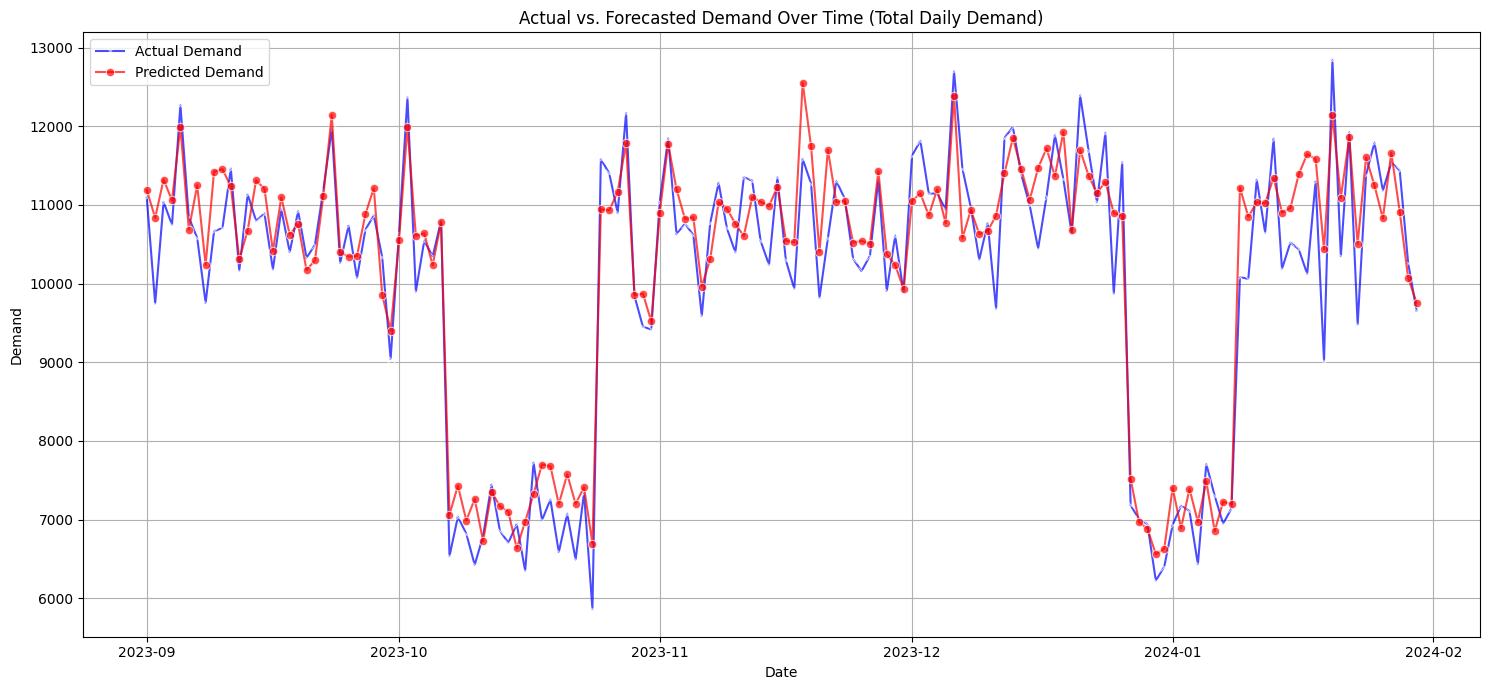

In [ ]:
df_daily_demand = df_results.groupby('Date')[['Actual Demand', 'Predicted Demand']].sum().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(
    data=df_daily_demand,
    x='Date', y='Actual Demand',
    label='Actual Demand',
    marker='x',
    color='blue',
    alpha=0.7
    )
sns.lineplot(
    data=df_daily_demand,
    x='Date',
    y='Predicted Demand',
    label='Predicted Demand',
    marker='o',
    color='red',
    alpha=0.7
    )

plt.title('Actual vs. Forecasted Demand Over Time (Total Daily Demand)')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Comprehensive Analysis and Optimal Stocking Recommendations

### Subtask:
Based on the results of ABC/XYZ analysis and demand forecasting, provide specific stocking recommendations for each product group to optimize inventory and minimize costs.

**Reasoning**:
The first step is to combine `df_combined_classification` with relevant columns from `df_abc` and `df_xyz` to create a single DataFrame (`df_analysis`). This will provide a consolidated view of product classifications (ABC and XYZ), total units sold, mean demand, and demand variability for each product.



In [ ]:
df_analysis = pd.merge(
    df_combined_classification,
    df_abc[['Product ID', 'Units Sold']],
    on='Product ID')
df_analysis = pd.merge(
    df_analysis,
    df_xyz[['Product ID', 'Mean_Demand', 'CV']],
    on='Product ID')

print(df_analysis.head())
print(f"\nShape of df_analysis: {df_analysis.shape}")

  Product ID ABC Class XYZ Class ABC_XYZ_Class  Units Sold  Mean_Demand  \
0      P0007         A         Z            AZ      379709   575.117105   
1      P0004         A         Z            AZ      377627   576.980263   
2      P0009         A         Y            AY      376771   592.531579   
3      P0013         A         Z            AZ      376717   580.125000   
4      P0002         A         Z            AZ      359355   560.332895   

          CV  
0  28.032811  
1  28.091673  
2  23.713397  
3  28.929285  
4  26.160533  

Shape of df_analysis: (20, 7)


**Reasoning**:
Now that `df_analysis` contains all the relevant information, I will group it by 'ABC_XYZ_Class' and calculate the mean of 'Units Sold', 'Mean_Demand', and 'CV' for each group. This will provide aggregate statistics to understand the characteristics of each combined product classification, fulfilling step 2 and 3 of the instructions.



In [ ]:
df_analysis_grouped = df_analysis.groupby('ABC_XYZ_Class').agg(
    Total_Units_Sold=('Units Sold', 'sum'),
    Avg_Mean_Demand=('Mean_Demand', 'mean'),
    Avg_CV=('CV', 'mean'),
    Num_Products=('Product ID', 'count')
).reset_index()

print(df_analysis_grouped)

  ABC_XYZ_Class  Total_Units_Sold  Avg_Mean_Demand     Avg_CV  Num_Products
0            AY            376771       592.531579  23.713397             1
1            AZ           4881164       536.648402  27.225343            14
2            BY            623806       492.867763  23.364167             2
3            BZ            296256       456.861842  29.866705             1
4            CZ            572879       441.754605  30.512074             2


### Recommendations for Inventory Management based on ABC-XYZ Classification

Based on the combined ABC-XYZ classification and the aggregated characteristics, here are strategic recommendations for inventory management, forecasting, and ordering:

**1. AZ Products (High Value, High Variability):**
*   **Characteristics**: These are high-value items (`A` class) with high demand variability (`Z` class). They contribute significantly to overall sales but have unpredictable demand.
*   **Recommendation**: Implement advanced forecasting models (e.g., time series models with external factors, machine learning models) that can capture volatility. Maintain buffer stock to prevent stockouts but avoid excessive inventory due to high holding costs and obsolescence risk. Focus on supplier relationships for quick replenishment. Consider flexible production or just-in-time (JIT) strategies where feasible to minimize inventory risk. Closely monitor demand fluctuations.

**2. AY Products (High Value, Medium Variability):**
*   **Characteristics**: High-value items (`A` class) with moderate demand variability (`Y` class).
*   **Recommendation**: Use robust statistical forecasting methods. Maintain a reasonable safety stock to cover demand fluctuations. Focus on service levels and ensure high availability, as these products are important revenue generators. Regular review of inventory levels and reorder points.

**3. AX Products (High Value, Low Variability):**
*   **Characteristics**: High-value items (`A` class) with stable demand (`X` class). These are the "cash cows" of the business.
*   **Recommendation**: Implement lean inventory management. Accurate forecasting with minimal safety stock. Focus on operational efficiency to minimize holding costs. High service levels are critical. Explore opportunities for bulk purchasing or long-term contracts with suppliers to reduce unit costs.

**4. BZ Products (Medium Value, High Variability):**
*   **Characteristics**: Medium-value items (`B` class) with high demand variability (`Z` class).
*   **Recommendation**: Balance cost and risk. Utilize forecasting but acknowledge its limitations due to high variability. Consider holding a slightly higher safety stock than `AY` products, but be wary of overstocking. Prioritize cost-effective inventory solutions. Monitor inventory turnover closely to prevent obsolescence.

**5. BY Products (Medium Value, Medium Variability):**
*   **Characteristics**: Medium-value items (`B` class) with moderate demand variability (`Y` class).
*   **Recommendation**: Standard forecasting and inventory management techniques. Maintain moderate safety stock. Focus on optimizing ordering costs and holding costs. Periodic review of inventory performance.

**6. BX Products (Medium Value, Low Variability):**
*   **Characteristics**: Medium-value items (`B` class) with stable demand (`X` class).
*   **Recommendation**: Routine inventory management. Standard forecasting. Automated reordering systems can be effective. Keep safety stock at a minimum due to stable demand and moderate value.

**7. CZ Products (Low Value, High Variability):**
*   **Characteristics**: Low-value items (`C` class) with high demand variability (`Z` class).
*   **Recommendation**: These are problematic items. Minimize inventory holdings to reduce obsolescence risk and carrying costs. Consider make-to-order or frequent, small batch orders. Look for opportunities to simplify the product or discontinue it if it doesn't meet strategic goals. Focus on reducing acquisition costs.

**8. CY Products (Low Value, Medium Variability):**
*   **Characteristics**: Low-value items (`C` class) with moderate demand variability (`Y` class).
*   **Recommendation**: Simple inventory control. Focus on minimizing administrative costs of ordering and holding. Group with other `C` class items for purchasing to gain economies of scale. Consider a two-bin system or similar low-overhead approaches.

**9. CX Products (Low Value, Low Variability):**
*   **Characteristics**: Low-value items (`C` class) with stable demand (`X` class).
*   **Recommendation**: High volume, low margin products. Keep sufficient stock with minimal safety stock. Focus on highly efficient procurement and automated inventory processes to keep costs down. Bulk ordering is often appropriate.

**Overall Strategy for Optimal Inventory:**
*   **Technology**: Leverage demand forecasting models (like the Random Forest Regressor developed) for all product categories, adjusting complexity based on variability.
*   **Supplier Management**: Develop strong relationships with suppliers, especially for A and high-variability products, to negotiate better terms and faster lead times.
*   **Continuous Monitoring**: Regularly review inventory performance, forecast accuracy, and classification of products as market conditions change.
*   **Integrated Planning**: Ensure close collaboration between sales, marketing, and operations to align demand forecasts with inventory planning and promotions.

## Final Task

### Subtask:
Summarize the entire ABC/XYZ analysis and demand forecasting process, presenting key findings, forecasting model performance, and specific stocking recommendations to optimize inventory and achieve business goals.

## Summary:

### Data Analysis Key Findings

*   **Data Preparation**:
    *   Successfully aggregated 'Units Sold' and 'Demand' by 'Date' and 'Product ID', resulting in 15200 unique entries without missing values.
    *   New time-based features (Year, Month, DayOfWeek, DayOfYear) were extracted from the 'Date' column.
    *   Operational variables like 'Price', 'Discount', 'Competitor Pricing', 'Promotion', 'Epidemic', 'Weather Condition', and 'Seasonality' were incorporated as features through appropriate aggregation (mean, max, mode) and one-hot encoding for categorical variables.
    *   The dataset was chronologically split into training (12160 samples) and testing (3040 samples) sets for time-series forecasting.
*   **ABC Classification**:
    *   Based on 'Units Sold', products were classified into 'A' (15 products, contributing to ~80% of sales), 'B' (3 products, contributing to next ~15%), and 'C' (2 products, contributing to remaining ~5%).
*   **XYZ Classification**:
    *   Based on demand variability (Coefficient of Variation), the majority of products were classified as 'Z' (high variability), with some as 'Y' (medium variability), and none as 'X' (low variability). This indicates a generally volatile demand pattern across the product portfolio.
*   **Combined ABC-XYZ Classification**:
    *   Merging ABC and XYZ classifications revealed 'AZ' as the most frequent category (14 products), indicating a significant number of high-value products with high demand variability. Other categories included 'BY' (2 products), 'CZ' (2 products), 'AY' (1 product), and 'BZ' (1 product).
*   **Demand Forecasting Model Performance**:
    *   A RandomForestRegressor model was trained to forecast 'Demand'.
    *   The model achieved a Mean Absolute Error (MAE) of 68.33, Root Mean Squared Error (RMSE) of 90.43, and a Mean Absolute Percentage Error (MAPE) of 15.09% on the test set.
    *   Visualizations confirmed that the model generally captured the overall trend of actual demand over time.

### Insights or Next Steps

*   The prevalence of 'AZ' products (high value, high variability) highlights a critical area for inventory management, requiring advanced forecasting techniques and robust safety stock strategies to balance service levels and holding costs.
*   The current forecasting model provides a reasonable baseline (MAPE of 15.09%), but further optimization by exploring alternative models (e.g., Prophet, ARIMA for individual products) or incorporating more leading indicators could improve accuracy, especially for 'Z' class products.
*   Implement differentiated inventory strategies based on the ABC-XYZ classification, such as implementing lean inventory for 'AX' products, while maintaining strategic buffer stocks and close supplier relationships for 'AZ' products, and minimizing holdings for 'CZ' products to reduce risk.
